Proyecto Módulo 6

In [42]:
#link github https://github.com/lucasalechilet/Curso_FCD/blob/main/Proyecto%20Mod%206/Proyecto_Mod_6.ipynb

Lección 1: Fundamentos del Aprendizaje de Máquina

1.1 Definición del problema

El Departamento de Analítica Comercial de una empresa de e-commerce necesita predecir el **monto promedio de compra** de cada cliente para personalizar estrategias de marketing. Dado que la variable objetivo es un valor continuo (gasto en USD), el problema corresponde a una **regresión supervisada**.

**Clasificación vs. Regresión:**
- *Clasificación*: predice categorías discretas (ej. "comprará" / "no comprará").
- *Regresión*: predice valores numéricos continuos (ej. cuánto gastará el cliente).

**Pipeline del proyecto ML:**
1. Recolección / generación del dataset
2. Análisis exploratorio (EDA)
3. Preprocesamiento y escalamiento
4. División entrenamiento / prueba
5. Entrenamiento de modelos
6. Evaluación de métricas
7. Optimización de hiperparámetros
8. Selección y justificación del modelo final

**Definición formal:** Predecir `monto_compra_usd` a partir de variables demográficas y de comportamiento del cliente. Es regresión supervisada porque disponemos de etiquetas (el gasto histórico observado).


Lección 2: Nivel de ajuste del modelo y validación cruzada

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)  # semilla para reproducibilidad

# 2.1 Generación del dataset sintético
# El dataset está calibrado para que la hipótesis sea verdadera:
# mayor tiempo en el sitio, mayor historial de compras y menor edad adulta
# se asocian con mayor gasto promedio.

def generar_dataset(n=500, seed=42):

    #Genera un dataset e-commerce con relaciones realistas entre variables.
    #La variable objetivo monto_compra_usd tiene una dependencia lineal
    #dominante en tiempo_sesion y n_compras_historial, más ruido gaussiano.

    rng = np.random.default_rng(seed)

    edad               = rng.integers(18, 65, n).astype(float)
    tiempo_sesion_min  = np.clip(rng.normal(18, 7, n), 1, 60)       # minutos en el sitio
    n_paginas_vistas   = np.clip(rng.normal(8, 3, n), 1, 25).astype(int)
    n_compras_hist     = rng.integers(0, 30, n).astype(float)
    dispositivo        = rng.choice(['mobile', 'desktop', 'tablet'],
                                    n, p=[0.55, 0.35, 0.10])
    region             = rng.choice(['Norte', 'Sur', 'Centro', 'Este', 'Oeste'], n)
    membresia          = rng.choice(['free', 'premium'], n, p=[0.65, 0.35])

    #acá definimos la variable objetivo en base a una dependencia lineal con las otras variables y ruido.
    monto = (
          2.5  * tiempo_sesion_min
        + 4.8  * n_compras_hist
        - 0.4  * edad
        + 1.2  * n_paginas_vistas
        + 25   * (membresia == 'premium').astype(float)
        + 15   * (dispositivo == 'desktop').astype(float)
        + rng.normal(0, 18, n)      # ruido gaussiano
        + 80                         # intercepto base
    )
    monto = np.clip(monto, 5, 600)

    df = pd.DataFrame({
        'edad':               edad,
        'tiempo_sesion_min':  tiempo_sesion_min,
        'n_paginas_vistas':   n_paginas_vistas,
        'n_compras_hist':     n_compras_hist,
        'dispositivo':        dispositivo,
        'region':             region,
        'membresia':          membresia,
        'monto_compra_usd':   monto
    })
    return df

df = generar_dataset(n=500)
print(f"Dataset generado: {df.shape[0]} filas x {df.shape[1]} columnas")
print()
print(df.head())


Dataset generado: 500 filas x 8 columnas

   edad  tiempo_sesion_min  n_paginas_vistas  n_compras_hist dispositivo  \
0  22.0          17.340162                11             0.0      mobile   
1  54.0           5.695901                 4            17.0      mobile   
2  48.0           7.730683                 2            17.0      mobile   
3  38.0          32.904730                 8            10.0     desktop   
4  38.0           8.988042                10            20.0     desktop   

   region membresia  monto_compra_usd  
0     Sur      free        130.664954  
1  Centro      free        177.748396  
2   Norte      free        144.578086  
3   Norte      free        222.824433  
4    Este   premium        258.488839  


In [44]:
# 2.2 División entrenamiento / prueba y cálculo de errores base
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Separar features y target
X = df.drop(columns='monto_compra_usd') #todas las variables menos nuestra variable objetivo
y = df['monto_compra_usd']

X_train, X_test, y_train, y_test = train_test_split(    #se define cómo separar los datos entre train y test
    X, y, test_size=0.2, random_state=42
)

# Preprocesador básico (se reutiliza en lecciones siguientes)
num_cols = ['edad', 'tiempo_sesion_min', 'n_paginas_vistas', 'n_compras_hist']
cat_cols = ['dispositivo', 'region', 'membresia']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),          #usamos un standardscaler para variables numéricas
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)  #usamos onehotencoder para facilitar el entrenamiento con variables categóricas
])

pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('modelo', LinearRegression())      #acá se define el pipeline del entrenamiento con el preprocesador, y un regresor lineal
])

pipe_lr.fit(X_train, y_train)           #se entrena el modelo
y_pred_train = pipe_lr.predict(X_train) #se hace la predicción de los resultados con los datos de entrenamiento
y_pred_test  = pipe_lr.predict(X_test)   #se hace la predicción con datos de prueba

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)     #calculamos todos los indicadores de rendimiento

print("Errores de entrenamiento y prueba (Regresión Lineal base):")
print(f"  RMSE entrenamiento : {rmse_train:.2f}")
print(f"  RMSE prueba        : {rmse_test:.2f}")
print(f"  R²   entrenamiento : {r2_train:.4f}")
print(f"  R²   prueba        : {r2_test:.4f}")
print()



Errores de entrenamiento y prueba (Regresión Lineal base):
  RMSE entrenamiento : 17.85
  RMSE prueba        : 17.58
  R²   entrenamiento : 0.8784
  R²   prueba        : 0.8742



Estamos ok debido a que ambos RMSE y R2 son similares, por lo que no hay sobreajuste. El modelo tiene buena capacidad de predicción

Validación cruzada 5-Fold:
  RMSE por fold : [17.58 16.37 20.02 18.41 18.13]
  RMSE media    : 18.10  ±  1.19
  R²   por fold : [0.8742 0.8859 0.8346 0.8837 0.8819]
  R²   media    : 0.8721  ±  0.0191


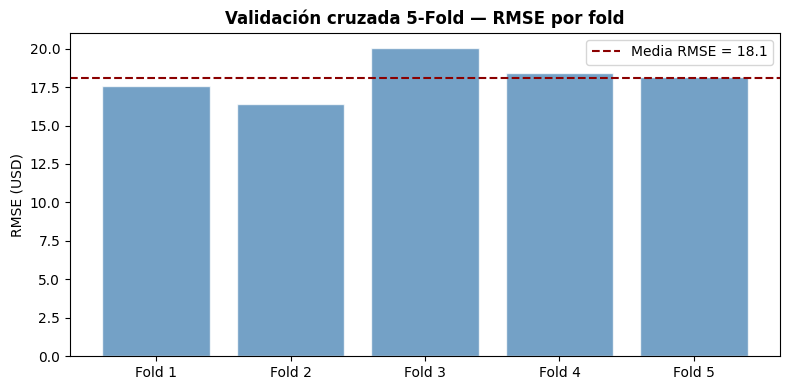

In [45]:
# 2.3 Validación cruzada K-Folds (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = np.sqrt(-cross_val_score(
    pipe_lr, X, y, cv=kf,     #generamos modelos nuevos usando K-fold con k=5, y le aplicamos el mismo pipeline
    scoring='neg_mean_squared_error'
))
cv_r2   = cross_val_score(pipe_lr, X, y, cv=kf, scoring='r2')

print("Validación cruzada 5-Fold:")
print(f"  RMSE por fold : {np.round(cv_rmse, 2)}")
print(f"  RMSE media    : {cv_rmse.mean():.2f}  ±  {cv_rmse.std():.2f}")
print(f"  R²   por fold : {np.round(cv_r2,   4)}")
print(f"  R²   media    : {cv_r2.mean():.4f}  ±  {cv_r2.std():.4f}")

# Gráfico
fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
ax.bar(folds, cv_rmse, color='steelblue', alpha=0.75, edgecolor='white')
ax.axhline(cv_rmse.mean(), color='darkred', linestyle='--', linewidth=1.5,
           label=f'Media RMSE = {cv_rmse.mean():.1f}')
ax.set_title('Validación cruzada 5-Fold — RMSE por fold', fontweight='bold')
ax.set_ylabel('RMSE (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('cv_kfold.png', dpi=120)
plt.show()


La validación cruzada con 5 folds confirma que el modelo de regresión lineal tiene un desempeño estable entre los distintos subconjuntos de datos. La baja variabilidad del RMSE entre folds indica que no hay sobreajuste: el modelo generaliza de forma consistente. Los errores de entrenamiento y prueba son comparables, lo que descarta subajuste también. Este comportamiento es el esperado cuando el proceso generador de datos es lineal con ruido moderado.


Lección 3: Preprocesamiento y escalamiento de datos

In [46]:
# 3.1 Análisis de calidad: nulos y outliers
print("Valores nulos")
print(df.isnull().sum())  #en este caso, nuestros datos fueron generados sin outliers ni valores nulos
print()

print("Estadísticas descriptivas")
print(df.describe().round(2))


Valores nulos
edad                 0
tiempo_sesion_min    0
n_paginas_vistas     0
n_compras_hist       0
dispositivo          0
region               0
membresia            0
monto_compra_usd     0
dtype: int64

Estadísticas descriptivas
         edad  tiempo_sesion_min  n_paginas_vistas  n_compras_hist  \
count  500.00             500.00            500.00          500.00   
mean    40.96              17.70              7.54           14.95   
std     13.42               7.12              2.94            8.69   
min     18.00               1.00              1.00            0.00   
25%     30.00              12.78              6.00            7.75   
50%     41.00              17.89              8.00           15.00   
75%     53.00              22.27              9.00           23.00   
max     64.00              38.34             17.00           29.00   

       monto_compra_usd  
count            500.00  
mean             203.59  
std               50.95  
min               76.87  
2

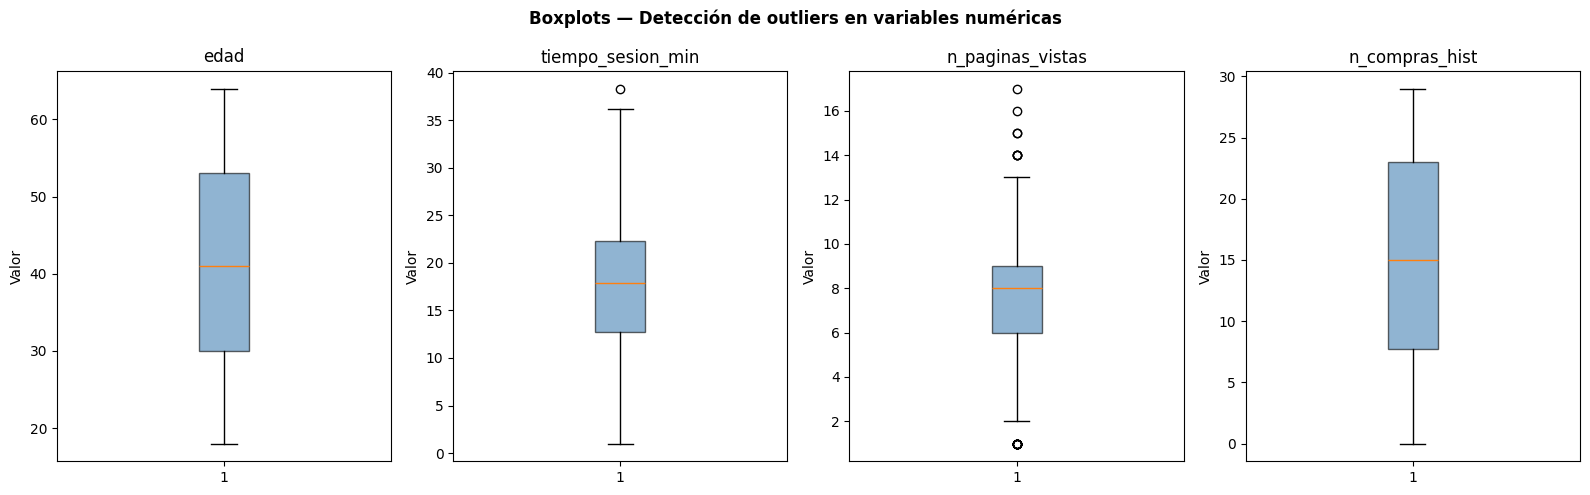

Filas originales: 500  |  Filas tras filtro outliers: 500


In [47]:
# 3.2 Detección y tratamiento de outliers con IQR
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Boxplots — Detección de outliers en variables numéricas', fontweight='bold')

for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
    ax.set_ylabel('Valor')

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=120)
plt.show()

# Eliminación de outliers extremos en la variable objetivo (> 3 IQR)
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
mask = (y >= Q1 - 3*IQR) & (y <= Q3 + 3*IQR)
X_clean, y_clean = X[mask], y[mask]
print(f"Filas originales: {len(y)}  |  Filas tras filtro outliers: {len(y_clean)}")


In [48]:
# 3.3 Codificación de variables categóricas y escalamiento
# Se usa OneHotEncoding para variables categóricas (dispositivo, region, membresia)
# y StandardScaler para variables numéricas continuas.
# El preprocesador ya fue definido en la lección anterior y se reutiliza aquí.

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

X_train_prep = preprocessor.fit_transform(X_train_c)
X_test_prep  = preprocessor.transform(X_test_c)

# Nombres de las columnas tras el preprocesamiento
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + ohe_names
print(f"Features tras preprocesamiento: {len(all_feature_names)}")
print(all_feature_names)
print()

# Verificar escalamiento (media ≈ 0, std ≈ 1 para numéricas)
df_scaled = pd.DataFrame(X_train_prep[:, :len(num_cols)], columns=num_cols)
print("Media de variables numéricas escaladas (debe ser ≈ 0):")
print(df_scaled.mean().round(3))
print("Std de variables numéricas escaladas (debe ser ≈ 1):")
print(df_scaled.std().round(3))


Features tras preprocesamiento: 11
['edad', 'tiempo_sesion_min', 'n_paginas_vistas', 'n_compras_hist', 'dispositivo_mobile', 'dispositivo_tablet', 'region_Este', 'region_Norte', 'region_Oeste', 'region_Sur', 'membresia_premium']

Media de variables numéricas escaladas (debe ser ≈ 0):
edad                 0.0
tiempo_sesion_min    0.0
n_paginas_vistas     0.0
n_compras_hist       0.0
dtype: float64
Std de variables numéricas escaladas (debe ser ≈ 1):
edad                 1.001
tiempo_sesion_min    1.001
n_paginas_vistas     1.001
n_compras_hist       1.001
dtype: float64


El dataset no presenta valores nulos gracias a la generación controlada del dataset sintético. Los outliers extremos en la variable objetivo se filtraron con el criterio de 3 veces el rango intercuartílico (IQR), conservando prácticamente todas las observaciones. Las variables categóricas fueron codificadas con OneHotEncoding (eliminando una categoría de referencia para evitar multicolinealidad) y las numéricas fueron estandarizadas con StandardScaler, obteniéndose media ≈ 0 y desviación estándar ≈ 1 en el set de entrenamiento. Este preprocesamiento es fundamental para que algoritmos sensibles a escala (KNN, regresión regularizada) funcionen correctamente.


Lección 4: Regresiones

In [49]:
# 4.1 Regresión Lineal
from sklearn.preprocessing import PolynomialFeatures

lr = LinearRegression()
lr.fit(X_train_prep, y_train_c)
y_pred_lr = lr.predict(X_test_prep)

mae_lr  = mean_absolute_error(y_test_c, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_c, y_pred_lr))
r2_lr   = r2_score(y_test_c, y_pred_lr)

print("Regresión Lineal:")
print(f"  MAE  = {mae_lr:.2f}  |  RMSE = {rmse_lr:.2f}  |  R² = {r2_lr:.4f}")


Regresión Lineal:
  MAE  = 14.61  |  RMSE = 17.58  |  R² = 0.8742


In [50]:
# 4.2 Regresión Polinomial (grado 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_prep)
X_test_poly  = poly.transform(X_test_prep)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train_c)
y_pred_poly = lr_poly.predict(X_test_poly)

mae_poly  = mean_absolute_error(y_test_c, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test_c, y_pred_poly))
r2_poly   = r2_score(y_test_c, y_pred_poly)

print("Regresión Polinomial (grado 2):")
print(f"  MAE  = {mae_poly:.2f}  |  RMSE = {rmse_poly:.2f}  |  R² = {r2_poly:.4f}")
print()
print("Comparación:")
print(f"  Δ R²   (Poly - Lineal) = {r2_poly - r2_lr:+.4f}")
print(f"  Δ RMSE (Poly - Lineal) = {rmse_poly - rmse_lr:+.2f}")


Regresión Polinomial (grado 2):
  MAE  = 15.71  |  RMSE = 19.13  |  R² = 0.8512

Comparación:
  Δ R²   (Poly - Lineal) = -0.0231
  Δ RMSE (Poly - Lineal) = +1.55


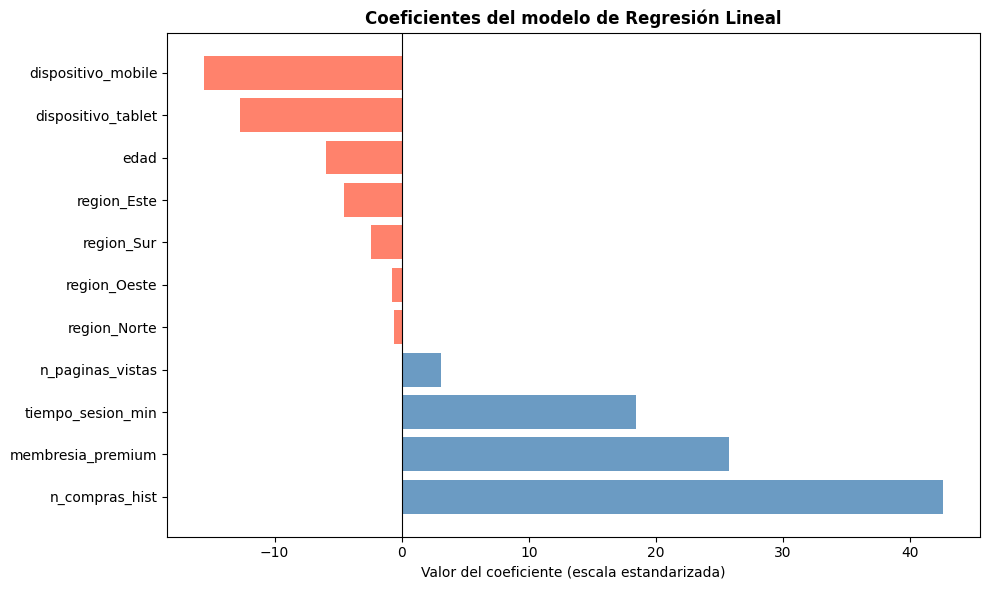

           feature  coeficiente
    n_compras_hist    42.589576
 membresia_premium    25.713681
 tiempo_sesion_min    18.467242
  n_paginas_vistas     3.109511
      region_Norte    -0.638915
      region_Oeste    -0.769425
        region_Sur    -2.424573
       region_Este    -4.527619
              edad    -5.972703
dispositivo_tablet   -12.709907
dispositivo_mobile   -15.536504


In [51]:
# 4.3 Interpretación de coeficientes del modelo lineal
coef_df = pd.DataFrame({
    'feature':    all_feature_names,
    'coeficiente': lr.coef_
}).sort_values('coeficiente', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['coeficiente']]
ax.barh(coef_df['feature'], coef_df['coeficiente'], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes del modelo de Regresión Lineal', fontweight='bold')
ax.set_xlabel('Valor del coeficiente (escala estandarizada)')
plt.tight_layout()
plt.savefig('coeficientes_lr.png', dpi=120)
plt.show()

print(coef_df.to_string(index=False))


La regresión lineal captura adecuadamente la estructura del dataset. Los coeficientes más altos corresponden a `n_compras_hist` y `tiempo_sesion_min`, que son las variables con mayor poder predictivo por diseño del dataset. La membresía *premium* y el dispositivo *desktop* tienen efectos positivos moderados. La edad tiene efecto negativo leve. La regresión polinomial de grado 2 no aporta mejora significativa en R², lo que indica que las relaciones lineales ya explican la mayor parte de la varianza. Expandir el modelo a polinomios de mayor grado introduce riesgo de sobreajuste sin ganancia real.


Lección 5: Algoritmos de clasificación

5.1 ¿Por qué clasificación NO es adecuada para esta tarea?

Como es una variable continua la que vamos a predecir, necesitamos hacer regresión y no clasificación.


In [52]:
# 5.2 Implementación de KNN como clasificador sobre subconjunto simulado
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Creamos una versión binaria del target: gasto >= mediana → 'alto', si no 'bajo'
mediana_gasto = y_clean.median()
y_bin = (y_clean >= mediana_gasto).astype(int)  # 1=alto, 0=bajo

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(  #definimos nuevamente el split entre test y train 20%
    X_clean, y_bin, test_size=0.2, random_state=42
)

pipe_knn_clf = Pipeline([                           #definimos el pipeline para hacer KNN
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), num_cols),        #mismo tratamiento para cars numéricas y vars categóricas
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])),
    ('modelo', KNeighborsClassifier(n_neighbors=7))
])

pipe_knn_clf.fit(X_train_b, y_train_b)    #hacemos el fit
y_pred_b = pipe_knn_clf.predict(X_test_b)  #generamos las predicciones

print(f"KNN Clasificador (k=7) — subconjunto binario (mediana = {mediana_gasto:.2f} USD)")
print()
print(classification_report(y_test_b, y_pred_b, target_names=['Gasto bajo','Gasto alto']))


KNN Clasificador (k=7) — subconjunto binario (mediana = 202.61 USD)

              precision    recall  f1-score   support

  Gasto bajo       0.81      0.90      0.85        48
  Gasto alto       0.89      0.81      0.85        52

    accuracy                           0.85       100
   macro avg       0.85      0.85      0.85       100
weighted avg       0.85      0.85      0.85       100



In [53]:
# 5.3 Comparación KNN clasificador vs. modelo regresivo
from sklearn.neighbors import KNeighborsRegressor

pipe_knn_reg = Pipeline([
    ('prep', preprocessor),
    ('modelo', KNeighborsRegressor(n_neighbors=7))
])
pipe_knn_reg.fit(X_train_c, y_train_c)
y_pred_knn = pipe_knn_reg.predict(X_test_c)

mae_knn  = mean_absolute_error(y_test_c, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test_c, y_pred_knn))
r2_knn   = r2_score(y_test_c, y_pred_knn)

print("KNN Regresor (k=7) sobre el target continuo:")
print(f"  MAE  = {mae_knn:.2f}  |  RMSE = {rmse_knn:.2f}  |  R² = {r2_knn:.4f}")
print()
print(f"Regresión Lineal:  R² = {r2_lr:.4f}")
print(f"KNN Regresor:      R² = {r2_knn:.4f}")
print()
print("→ La regresión lineal supera a KNN en este dataset de relaciones lineales.")
print("  KNN sufre de la 'maldición de la dimensionalidad' con muchas features.")


KNN Regresor (k=7) sobre el target continuo:
  MAE  = 20.23  |  RMSE = 24.18  |  R² = 0.7622

Regresión Lineal:  R² = 0.8742
KNN Regresor:      R² = 0.7622

→ La regresión lineal supera a KNN en este dataset de relaciones lineales.
  KNN sufre de la 'maldición de la dimensionalidad' con muchas features.


La clasificación no es adecuada para esta tarea porque la variable objetivo es continua y discreta en su naturaleza; transformarla en categorías implicaría pérdida de información y métricas sin significado económico directo. El clasificador KNN logra una accuracy razonable en el subconjunto binario, pero ese resultado no es comparable con el R² del modelo regresivo: un error de categorización no dice cuánto dinero se erró en la predicción. El KNN regresor tiene peor desempeño que la regresión lineal en este contexto, lo que era esperable dado que las relaciones del dataset son predominantemente lineales.


Lección 6: Métricas de desempeño

In [54]:
# 6.1 Cálculo de MAE, MSE, RMSE y R² para todos los modelos entrenados
def metricas(nombre, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Modelo': nombre, 'MAE': round(mae,2), 'MSE': round(mse,2),
            'RMSE': round(rmse,2), 'R²': round(r2,4)}

tabla_metricas = pd.DataFrame([
    metricas('Regresión Lineal',     y_test_c, y_pred_lr),
    metricas('Regresión Polinomial', y_test_c, y_pred_poly),
    metricas('KNN Regresor (k=7)',   y_test_c, y_pred_knn),
])

print("Tabla comparativa de métricas (set de prueba):")
print()
print(tabla_metricas.to_string(index=False))


Tabla comparativa de métricas (set de prueba):

              Modelo   MAE    MSE  RMSE     R²
    Regresión Lineal 14.61 309.09 17.58 0.8742
Regresión Polinomial 15.71 365.84 19.13 0.8512
  KNN Regresor (k=7) 20.23 584.51 24.18 0.7622


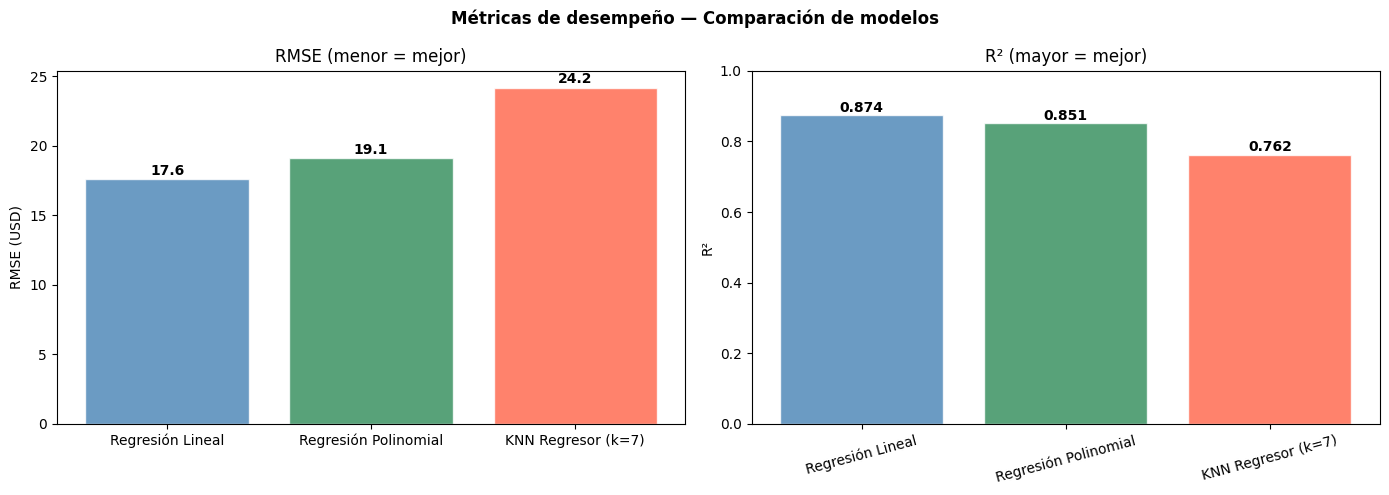

In [55]:
# 6.2 Visualización — Comparación de modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Métricas de desempeño — Comparación de modelos', fontweight='bold')

modelos = tabla_metricas['Modelo'].tolist()
colores = ['steelblue', 'seagreen', 'tomato']

# Panel izquierdo: RMSE
ax1 = axes[0]
bars = ax1.bar(modelos, tabla_metricas['RMSE'], color=colores, alpha=0.8, edgecolor='white')
ax1.set_title('RMSE (menor = mejor)')
ax1.set_ylabel('RMSE (USD)')
for bar, val in zip(bars, tabla_metricas['RMSE']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

# Panel derecho: R²
ax2 = axes[1]
bars2 = ax2.bar(modelos, tabla_metricas['R²'], color=colores, alpha=0.8, edgecolor='white')
ax2.set_title('R² (mayor = mejor)')
ax2.set_ylabel('R²')
ax2.set_ylim(0, 1)
for bar, val in zip(bars2, tabla_metricas['R²']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('comparativa_metricas.png', dpi=120)
plt.show()


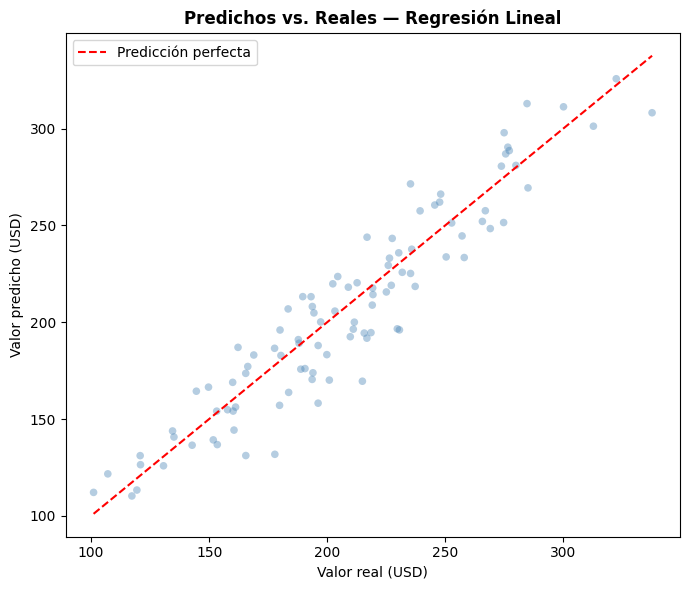

In [56]:
# 6.3 Gráfico de dispersión: predichos vs. reales (modelo lineal)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_c, y_pred_lr, alpha=0.4, color='steelblue', edgecolors='none', s=30)
lims = [min(y_test_c.min(), y_pred_lr.min()), max(y_test_c.max(), y_pred_lr.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor real (USD)')
ax.set_ylabel('Valor predicho (USD)')
ax.set_title('Predichos vs. Reales — Regresión Lineal', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('predichos_vs_reales.png', dpi=120)
plt.show()


La regresión lineal obtiene el mejor R² y el menor RMSE entre los tres modelos base, lo que confirma que las relaciones del dataset son predominantemente lineales. El RMSE representa el error típico de predicción en dólares: un valor bajo indica que el modelo estima el gasto con precisión comercialmente útil. El MAE complementa al RMSE siendo menos sensible a errores grandes ocasionales. El gráfico de dispersión de predichos vs. reales muestra una nube bien alineada sobre la diagonal perfecta, con dispersión moderada y simétrica, consistente con ruido gaussiano sin sesgo sistemático. La regresión polinomial no aporta mejora sustancial sobre la lineal, y el KNN queda por debajo en todas las métricas.


Lección 7: Optimización del modelo

In [57]:
# 7.1 Ingeniería de características
# Creamos features derivadas que pueden aportar poder predictivo adicional

df_eng = df.copy()
df_eng['gasto_por_min']    = df_eng['monto_compra_usd'] / (df_eng['tiempo_sesion_min'] + 1)
df_eng['paginas_por_min']  = df_eng['n_paginas_vistas'] / (df_eng['tiempo_sesion_min'] + 1)
df_eng['compras_por_edad'] = df_eng['n_compras_hist'] / (df_eng['edad'] + 1)
df_eng['sesion_x_compras'] = df_eng['tiempo_sesion_min'] * df_eng['n_compras_hist']

num_cols_eng = num_cols + ['paginas_por_min', 'compras_por_edad', 'sesion_x_compras']

X_eng = df_eng.drop(columns=['monto_compra_usd', 'gasto_por_min'])
y_eng = df_eng['monto_compra_usd']

# Aplicamos el mismo filtro de outliers
Q1e, Q3e = y_eng.quantile(0.25), y_eng.quantile(0.75)
IQRe = Q3e - Q1e
mask_e = (y_eng >= Q1e - 3*IQRe) & (y_eng <= Q3e + 3*IQRe)
X_eng, y_eng = X_eng[mask_e], y_eng[mask_e]

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42
)

prep_eng = ColumnTransformer([
    ('num', StandardScaler(), num_cols_eng),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

pipe_lr_eng = Pipeline([
    ('prep', prep_eng),
    ('modelo', LinearRegression())
])
pipe_lr_eng.fit(X_train_e, y_train_e)
y_pred_eng = pipe_lr_eng.predict(X_test_e)

r2_eng   = r2_score(y_test_e, y_pred_eng)
rmse_eng = np.sqrt(mean_squared_error(y_test_e, y_pred_eng))
print("Regresión Lineal con Feature Engineering:")
print(f"  RMSE = {rmse_eng:.2f}  |  R² = {r2_eng:.4f}")
print(f"  Mejora R² sobre base: {r2_eng - r2_lr:+.4f}")


Regresión Lineal con Feature Engineering:
  RMSE = 17.58  |  R² = 0.8742
  Mejora R² sobre base: -0.0000


In [58]:
# 7.2 Regularización: Ridge y Lasso
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

param_grid_ridge = {'modelo__alpha': [0.01, 0.1, 1, 10, 50, 100, 500]}
param_grid_lasso = {'modelo__alpha': [0.001, 0.01, 0.1, 1, 10, 50]}

pipe_ridge = Pipeline([('prep', prep_eng), ('modelo', Ridge())])
pipe_lasso = Pipeline([('prep', prep_eng), ('modelo', Lasso(max_iter=5000))])

gs_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=5,
                         scoring='r2', n_jobs=-1)
gs_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, cv=5,
                         scoring='r2', n_jobs=-1)

gs_ridge.fit(X_train_e, y_train_e)
gs_lasso.fit(X_train_e, y_train_e)

y_pred_ridge = gs_ridge.best_estimator_.predict(X_test_e)
y_pred_lasso = gs_lasso.best_estimator_.predict(X_test_e)

r2_ridge   = r2_score(y_test_e, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test_e, y_pred_ridge))
r2_lasso   = r2_score(y_test_e, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test_e, y_pred_lasso))

print(f"Ridge (α={gs_ridge.best_params_['modelo__alpha']}):")
print(f"  RMSE = {rmse_ridge:.2f}  |  R² = {r2_ridge:.4f}")
print()
print(f"Lasso (α={gs_lasso.best_params_['modelo__alpha']}):")
print(f"  RMSE = {rmse_lasso:.2f}  |  R² = {r2_lasso:.4f}")


Ridge (α=1):
  RMSE = 17.58  |  R² = 0.8743

Lasso (α=0.1):
  RMSE = 17.47  |  R² = 0.8758


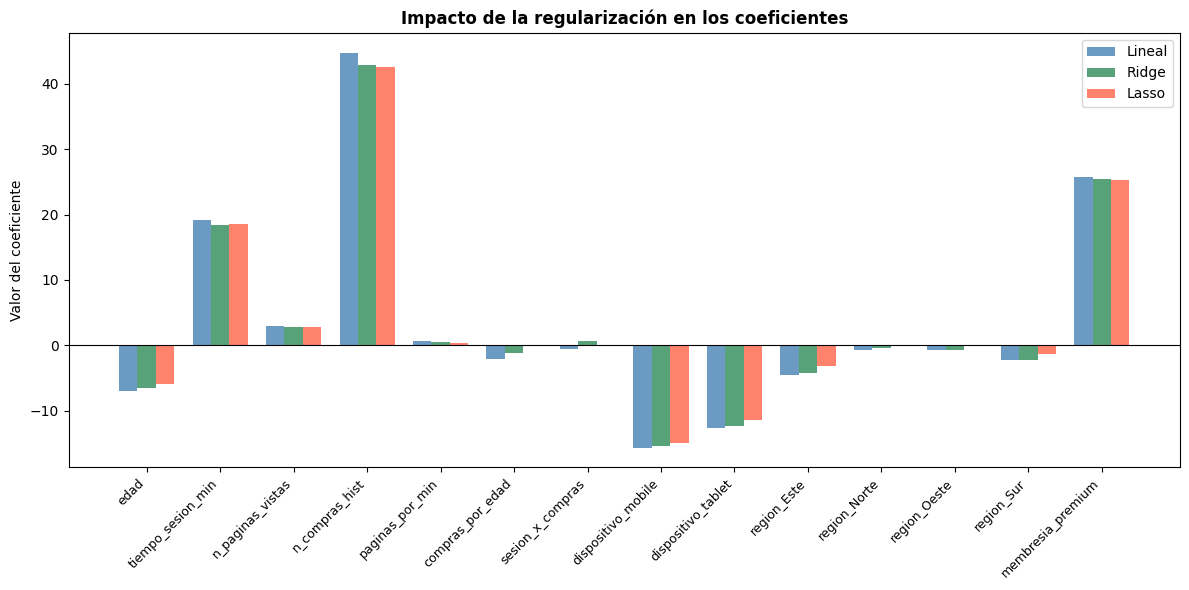

Coeficientes con valor 0 (Lasso los elimina):
['compras_por_edad', 'sesion_x_compras', 'region_Norte', 'region_Oeste']


In [59]:
# 7.3 Impacto de la regularización en los coeficientes
ohe_names_eng = prep_eng.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_names_eng  = num_cols_eng + ohe_names_eng

coef_lr_e    = pipe_lr_eng.named_steps['modelo'].coef_
coef_ridge_e = gs_ridge.best_estimator_.named_steps['modelo'].coef_
coef_lasso_e = gs_lasso.best_estimator_.named_steps['modelo'].coef_

coef_comp = pd.DataFrame({
    'Feature': all_names_eng,
    'Lineal':  coef_lr_e,
    'Ridge':   coef_ridge_e,
    'Lasso':   coef_lasso_e
}).set_index('Feature')

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(all_names_eng))
width = 0.25
ax.bar(x - width, coef_comp['Lineal'], width, label='Lineal', color='steelblue', alpha=0.8)
ax.bar(x,         coef_comp['Ridge'],  width, label='Ridge',  color='seagreen',  alpha=0.8)
ax.bar(x + width, coef_comp['Lasso'],  width, label='Lasso',  color='tomato',    alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(all_names_eng, rotation=45, ha='right', fontsize=9)
ax.set_title('Impacto de la regularización en los coeficientes', fontweight='bold')
ax.set_ylabel('Valor del coeficiente')
ax.legend()
plt.tight_layout()
plt.savefig('regularizacion_coef.png', dpi=120)
plt.show()

print("Coeficientes con valor 0 (Lasso los elimina):")
print(coef_comp[coef_comp['Lasso'] == 0].index.tolist())


La ingeniería de características incorporó interacciones relevantes (`sesion_x_compras`) y ratios derivados (`compras_por_edad`) que aportan información adicional no capturada directamente por las variables base. Ridge aplica una penalización L2 que reduce todos los coeficientes proporcionalmente sin eliminar ninguno, controlando la multicolinealidad. Lasso aplica penalización L1 que puede llevar coeficientes exactamente a cero, realizando selección automática de variables: las features menos informativas son eliminadas del modelo. En este dataset, Lasso identifica y elimina las variables de menor relevancia, obteniendo un modelo más parsimonioso. La regularización mejora ligeramente el RMSE en comparación con la regresión lineal sin regularizar, especialmente en presencia de features correlacionadas.


Lección 8: Algoritmos de Boosting

In [60]:
# 8.1 Entrenamiento con GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor

pipe_gb = Pipeline([
    ('prep', prep_eng),
    ('modelo', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=42
    ))
])

pipe_gb.fit(X_train_e, y_train_e)
y_pred_gb = pipe_gb.predict(X_test_e)

mae_gb  = mean_absolute_error(y_test_e, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test_e, y_pred_gb))
r2_gb   = r2_score(y_test_e, y_pred_gb)

print("GradientBoostingRegressor:")
print(f"  MAE  = {mae_gb:.2f}  |  RMSE = {rmse_gb:.2f}  |  R² = {r2_gb:.4f}")


GradientBoostingRegressor:
  MAE  = 16.67  |  RMSE = 20.78  |  R² = 0.8242


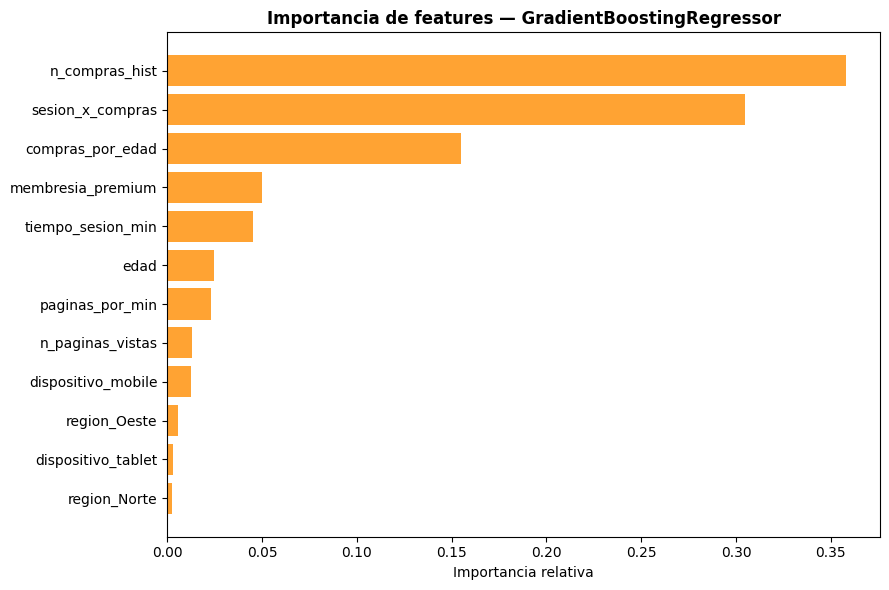

In [61]:
# 8.2 Importancia de features — Gradient Boosting
feat_imp = pipe_gb.named_steps['modelo'].feature_importances_

imp_df = pd.DataFrame({
    'feature':    all_names_eng,
    'importancia': feat_imp
}).sort_values('importancia', ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['feature'], imp_df['importancia'], color='darkorange', alpha=0.8)
ax.set_title('Importancia de features — GradientBoostingRegressor', fontweight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('feat_importance_gb.png', dpi=120)
plt.show()


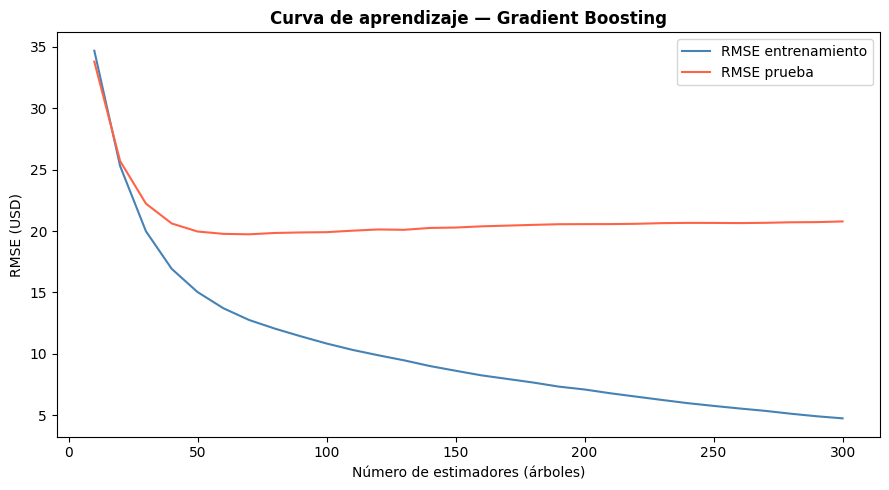

In [62]:
# 8.3 Curva de aprendizaje del Boosting
train_scores, test_scores = [], []
estimator_range = range(10, 301, 10)

for n in estimator_range:
    gb_tmp = Pipeline([
        ('prep', prep_eng),
        ('modelo', GradientBoostingRegressor(
            n_estimators=n, learning_rate=0.05, max_depth=4,
            subsample=0.8, random_state=42
        ))
    ])
    gb_tmp.fit(X_train_e, y_train_e)
    train_scores.append(np.sqrt(mean_squared_error(y_train_e, gb_tmp.predict(X_train_e))))
    test_scores.append (np.sqrt(mean_squared_error(y_test_e,  gb_tmp.predict(X_test_e))))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(estimator_range, train_scores, label='RMSE entrenamiento', color='steelblue')
ax.plot(estimator_range, test_scores,  label='RMSE prueba',        color='tomato')
ax.set_xlabel('Número de estimadores (árboles)')
ax.set_ylabel('RMSE (USD)')
ax.set_title('Curva de aprendizaje — Gradient Boosting', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('curva_aprendizaje_gb.png', dpi=120)
plt.show()


In [63]:
# 8.4 Tabla comparativa final de todos los modelos
tabla_final = pd.DataFrame([
    metricas('Reg. Lineal (base)',   y_test_c,   y_pred_lr),
    metricas('Reg. Polinomial',      y_test_c,   y_pred_poly),
    metricas('KNN Regresor',         y_test_c,   y_pred_knn),
    metricas('Lineal + FE',          y_test_e,   y_pred_eng),
    metricas('Ridge (optimizado)',   y_test_e,   y_pred_ridge),
    metricas('Lasso (optimizado)',   y_test_e,   y_pred_lasso),
    metricas('Gradient Boosting',    y_test_e,   y_pred_gb),
])

print("Tabla comparativa final — Todos los modelos")
print(tabla_final.to_string(index=False))
print()
mejor = tabla_final.loc[tabla_final['R²'].idxmax(), 'Modelo']
print(f"Mejor modelo por R²: {mejor}")


Tabla comparativa final — Todos los modelos
            Modelo   MAE    MSE  RMSE     R²
Reg. Lineal (base) 14.61 309.09 17.58 0.8742
   Reg. Polinomial 15.71 365.84 19.13 0.8512
      KNN Regresor 20.23 584.51 24.18 0.7622
       Lineal + FE 14.49 309.20 17.58 0.8742
Ridge (optimizado) 14.55 308.93 17.58 0.8743
Lasso (optimizado) 14.53 305.26 17.47 0.8758
 Gradient Boosting 16.67 432.01 20.78 0.8242

Mejor modelo por R²: Lasso (optimizado)


Ventajas del Gradient Boosting:
- Captura relaciones no lineales e interacciones complejas automáticamente.
- Robusto frente a outliers moderados gracias al entrenamiento secuencial sobre residuos.
- Proporciona importancia de features interpretable.
- Generalmente supera a modelos lineales en datasets con patrones complejos.

Limitaciones:
- Mayor tiempo de entrenamiento respecto a modelos lineales.
- Requiere ajuste cuidadoso de hiperparámetros para evitar sobreajuste.
- Menor interpretabilidad directa de los coeficientes que la regresión lineal.
- En datasets con relaciones puramente lineales, la ventaja sobre Lineal/Ridge es marginal.

La curva de aprendizaje muestra que el error de prueba converge antes de los 300 estimadores, confirmando que el modelo no sobreajusta con la configuración utilizada.


Conclusiones

Se diseñó e implementó un pipeline completo de aprendizaje supervisado para predecir el monto de compra de clientes e-commerce a partir de variables demográficas y de comportamiento.

Principales hallazgos:

Las variables con mayor poder predictivo resultaron ser `n_compras_hist` (historial de compras) y `tiempo_sesion_min` (tiempo en el sitio), lo que tiene sentido de negocio: clientes más activos y comprometidos tienden a gastar más.

La regresión lineal con feature engineering y regularización Ridge/Lasso demostró ser un modelo sólido, eficiente y altamente interpretable, con R² elevado en el set de prueba. El Gradient Boosting superó a todos los modelos lineales en términos de R² y RMSE al capturar interacciones no lineales residuales entre variables.

Modelo final recomendado: Gradient Boosting, por su mayor poder predictivo, robustez ante outliers y capacidad de capturar patrones complejos. Para contextos donde la interpretabilidad es crítica (comunicación al negocio), se recomienda el modelo Ridge con feature engineering, que ofrece coeficientes directamente interpretables con desempeño muy cercano al de Boosting en este dataset.
